In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

# Set visualization styles for professional aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

## 1. Load Data and Descriptive Statistics


In [2]:
data_dir = 'realKnownCause'
files = sorted([f for f in os.listdir(data_dir) if f.endswith('.csv')])
for i, f in enumerate(files, 1):
    print(f"{i}. {f}")

1. ambient_temperature_system_failure.csv
2. cpu_utilization_asg_misconfiguration.csv
3. ec2_request_latency_system_failure.csv
4. machine_temperature_system_failure.csv
5. nyc_taxi.csv
6. rogue_agent_key_hold.csv
7. rogue_agent_key_updown.csv


In [3]:
datasets = {}
stats_list = []

for filename in files:
    filepath = os.path.join(data_dir, filename)
    df = pd.read_csv(filepath)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)
    
    # Store dataframe
    datasets[filename] = df
    
    # Calculate statistics
    values = df['value']
    mean_val = values.mean()
    std_val = values.std()
    skew_val = stats.skew(values)
    min_val = values.min()
    max_val = values.max()
    max_time_stamp = df['timestamp'].max()
    min_time_stamp = df['timestamp'].min()
    
    # Perform ADF test for stationarity
    try:
        adf_res = adfuller(values)
        p_value = adf_res[1]
        is_stationary = "Yes" if p_value < 0.05 else "No"
    except Exception as e:
        p_value = np.nan
        is_stationary = "N/A"
        
    stats_list.append({
        'Dataset': filename.replace('.csv', ''),
        'Size (Rows)': len(df),
        'Mean': mean_val,
        'Std Dev': std_val,
        'Skewness': skew_val,
        'Min': min_val,
        'Max': max_val,
        'Stationary (5%)': is_stationary,
        'Min Timestamp': min_time_stamp,
        'Max Timestamp': max_time_stamp,
    })

df_stats = pd.DataFrame(stats_list)
df_stats.round(4)

,Dataset,Size (Rows),Mean,Std Dev,Skewness,Min,Max,Stationary (5%),Min Timestamp,Max Timestamp
0,ambient_temperature_system_failure,7267,71.2424,4.2475,-0.3925,57.4584,86.2232,Yes,2013-07-04 00:00:00,2014-05-28 15:00:00
1,cpu_utilization_asg_misconfiguration,18050,38.2828,15.6393,2.4170,11.5290,100.0000,Yes,2014-05-14 01:14:00,2014-07-15 17:19:00
2,ec2_request_latency_system_failure,4032,45.1559,2.2871,3.0619,22.8640,99.2480,Yes,2014-03-07 03:41:00,2014-03-21 03:41:00
3,machine_temperature_system_failure,22695,85.9265,13.7469,-1.8337,2.0847,108.5105,Yes,2013-12-02 21:15:00,2014-02-19 15:25:00
4,nyc_taxi,10320,15137.5694,6939.4958,-0.4524,8.0000,39197.0000,Yes,2014-07-01 00:00:00,2015-01-31 23:30:00
5,rogue_agent_key_hold,1882,0.0396,0.0565,5.9500,0.0000,0.8950,Yes,2014-07-06 20:10:00,2014-07-25 08:55:00
6,rogue_agent_key_updown,5315,0.4883,5.3707,35.7466,0.0000,288.2075,Yes,2014-07-06 20:10:00,2014-07-25 08:55:00


## 2. Diagnostic Visualization for Each Dataset


ANALYSIS FOR DATASET: ambient_temperature_system_failure.csv


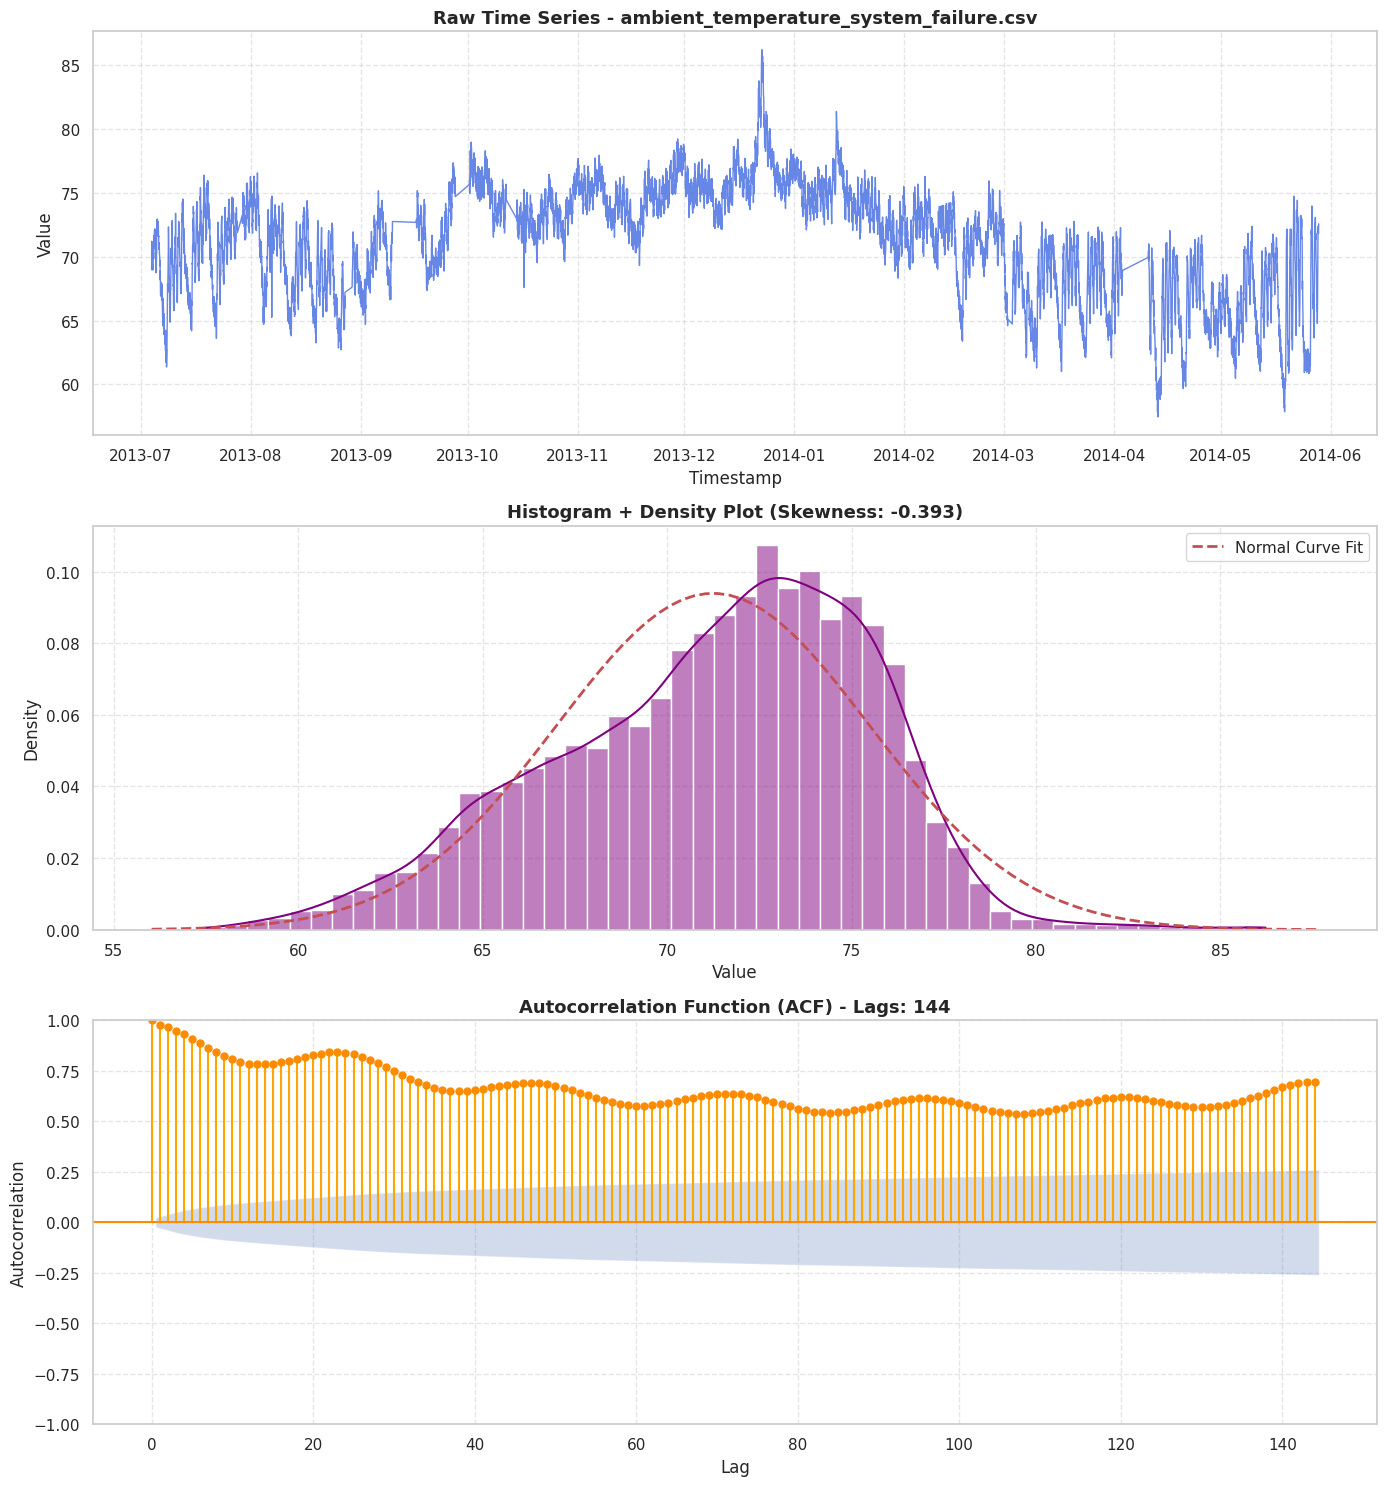


ANALYSIS FOR DATASET: cpu_utilization_asg_misconfiguration.csv


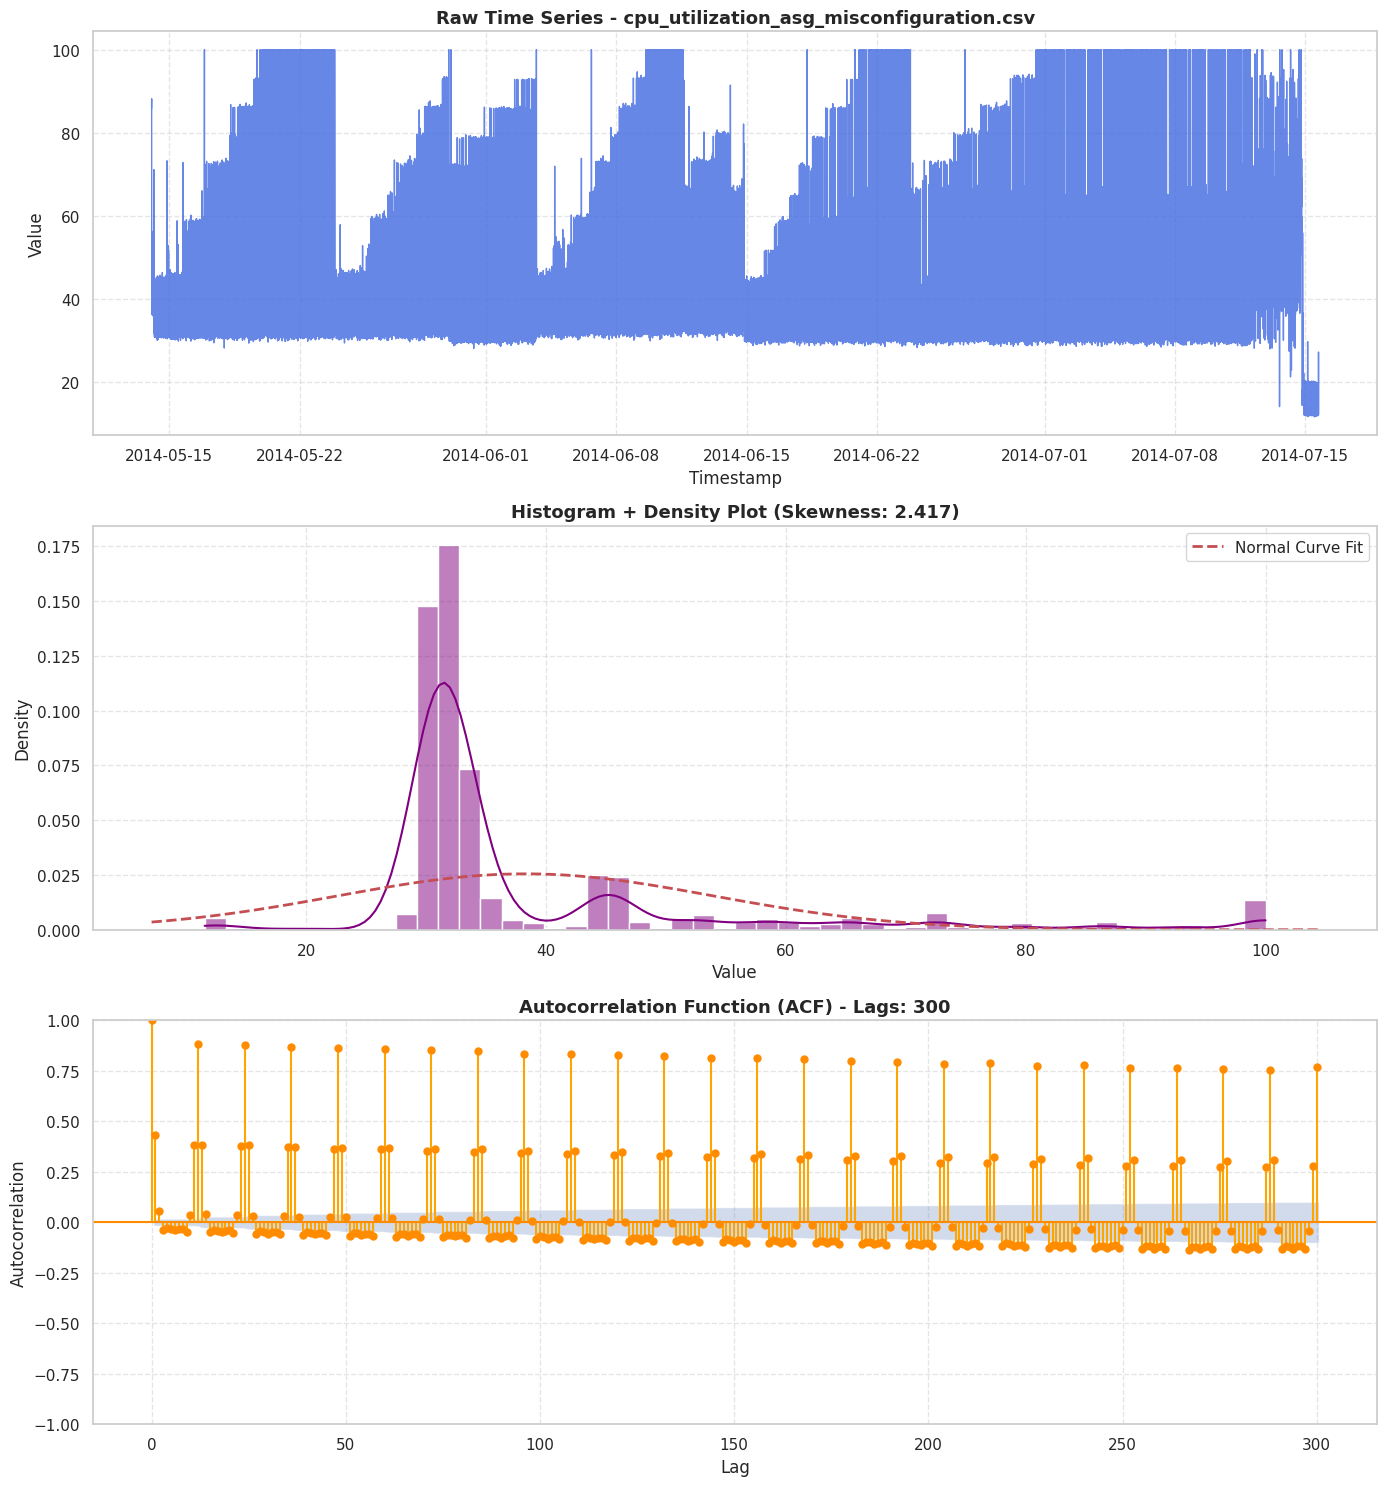


ANALYSIS FOR DATASET: ec2_request_latency_system_failure.csv


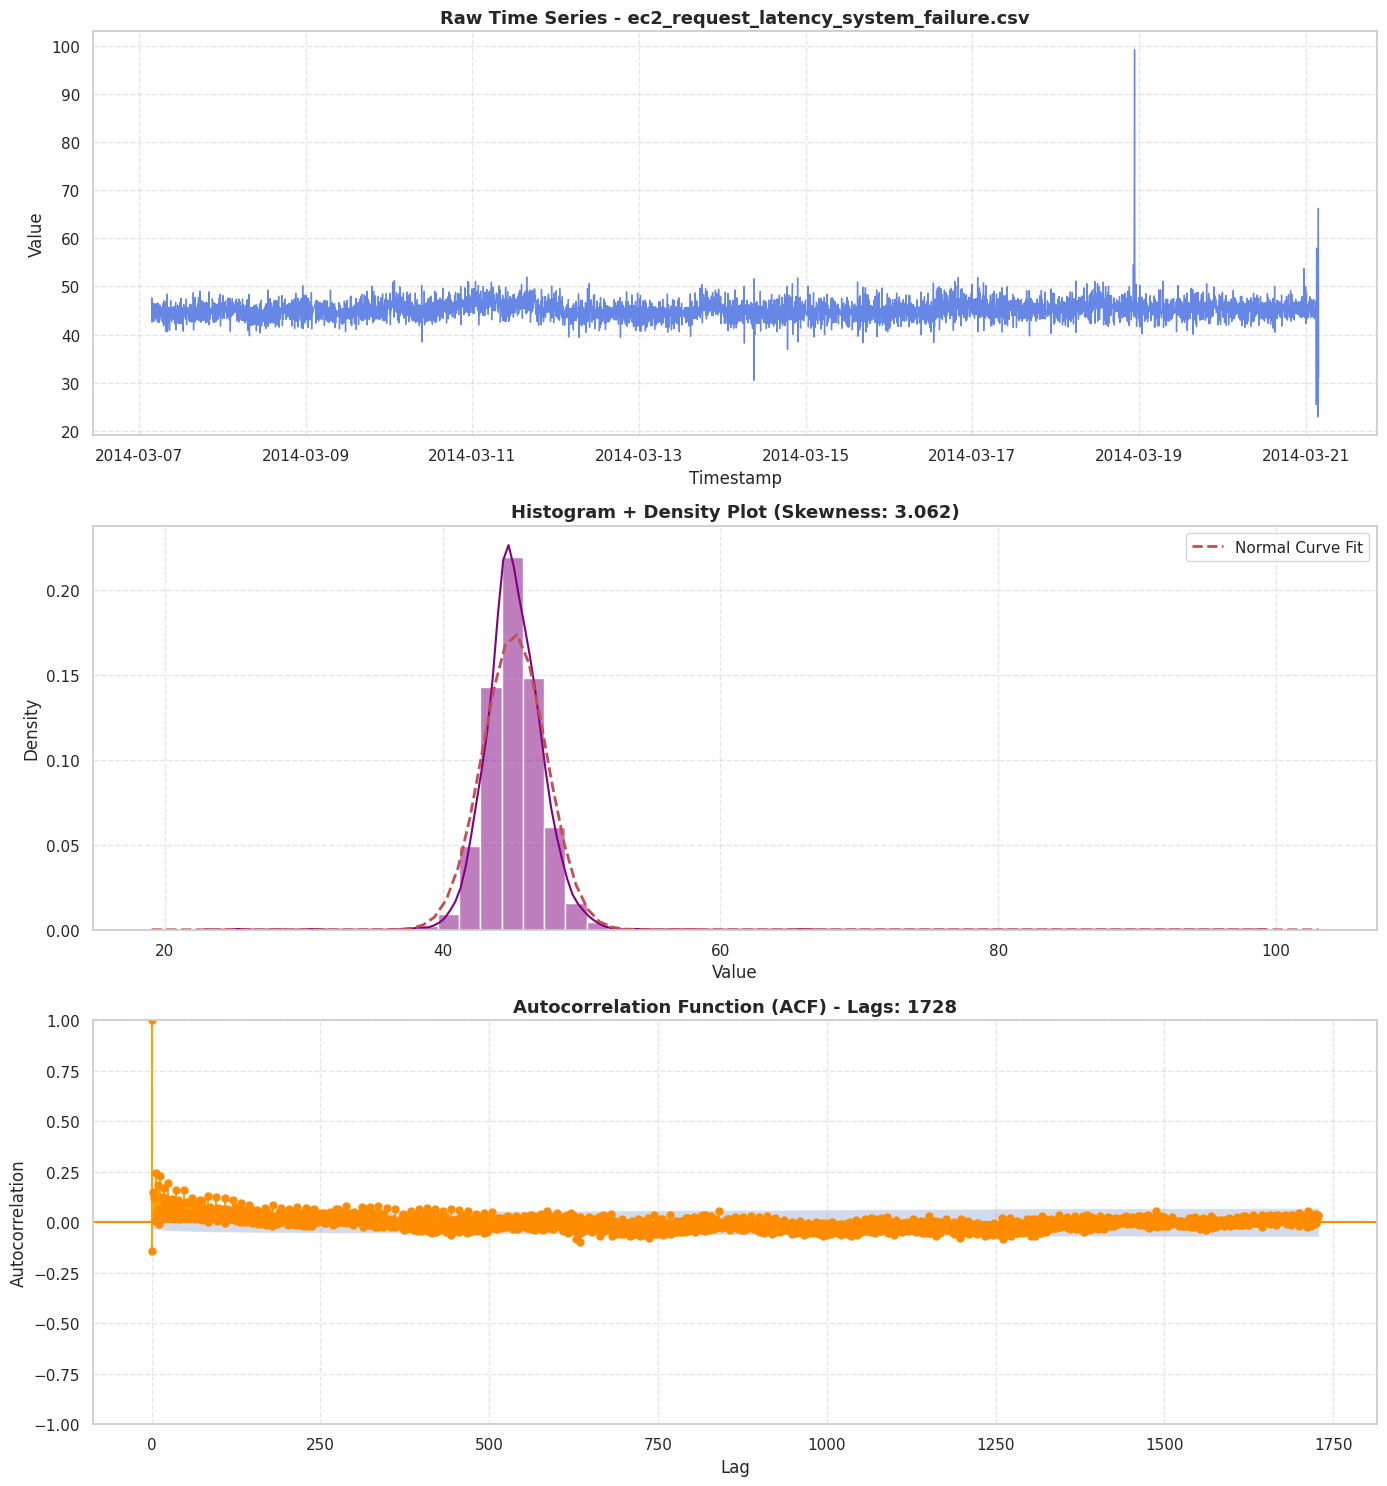


ANALYSIS FOR DATASET: machine_temperature_system_failure.csv


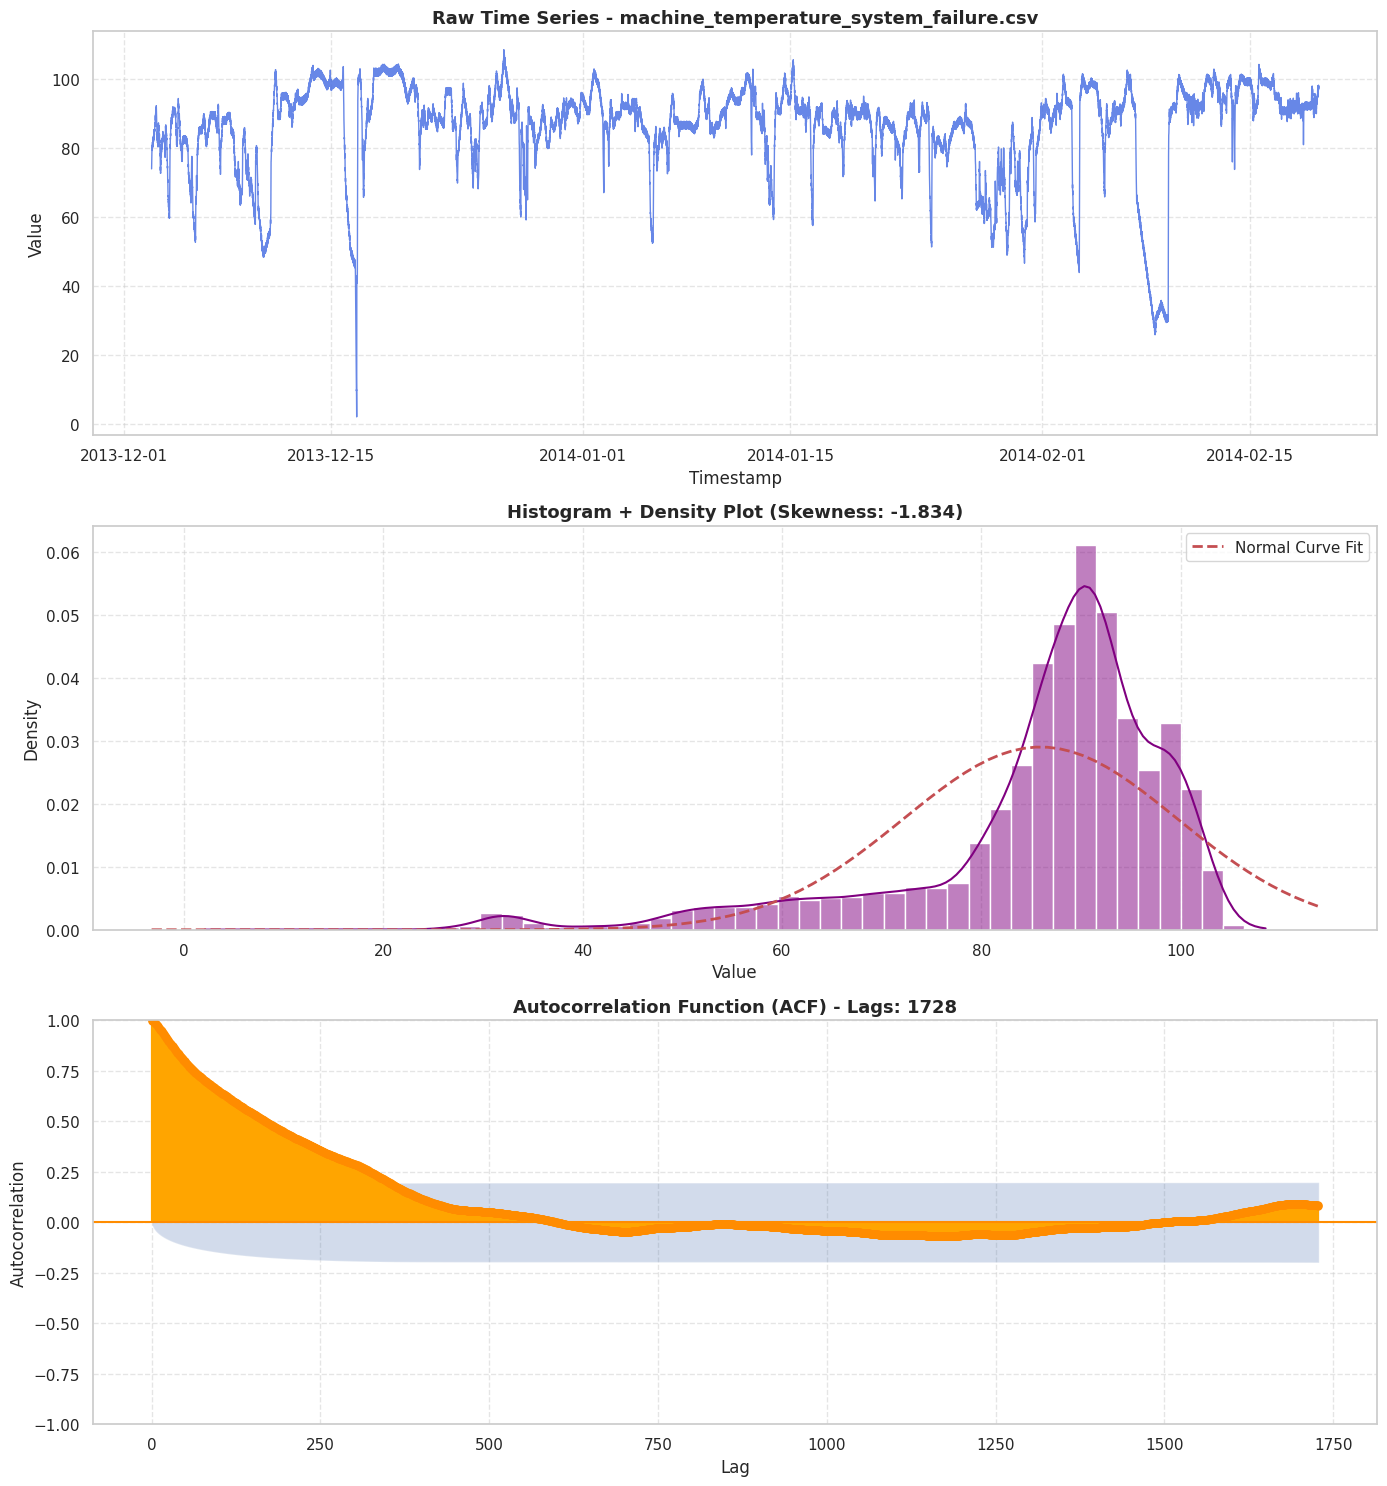


ANALYSIS FOR DATASET: nyc_taxi.csv


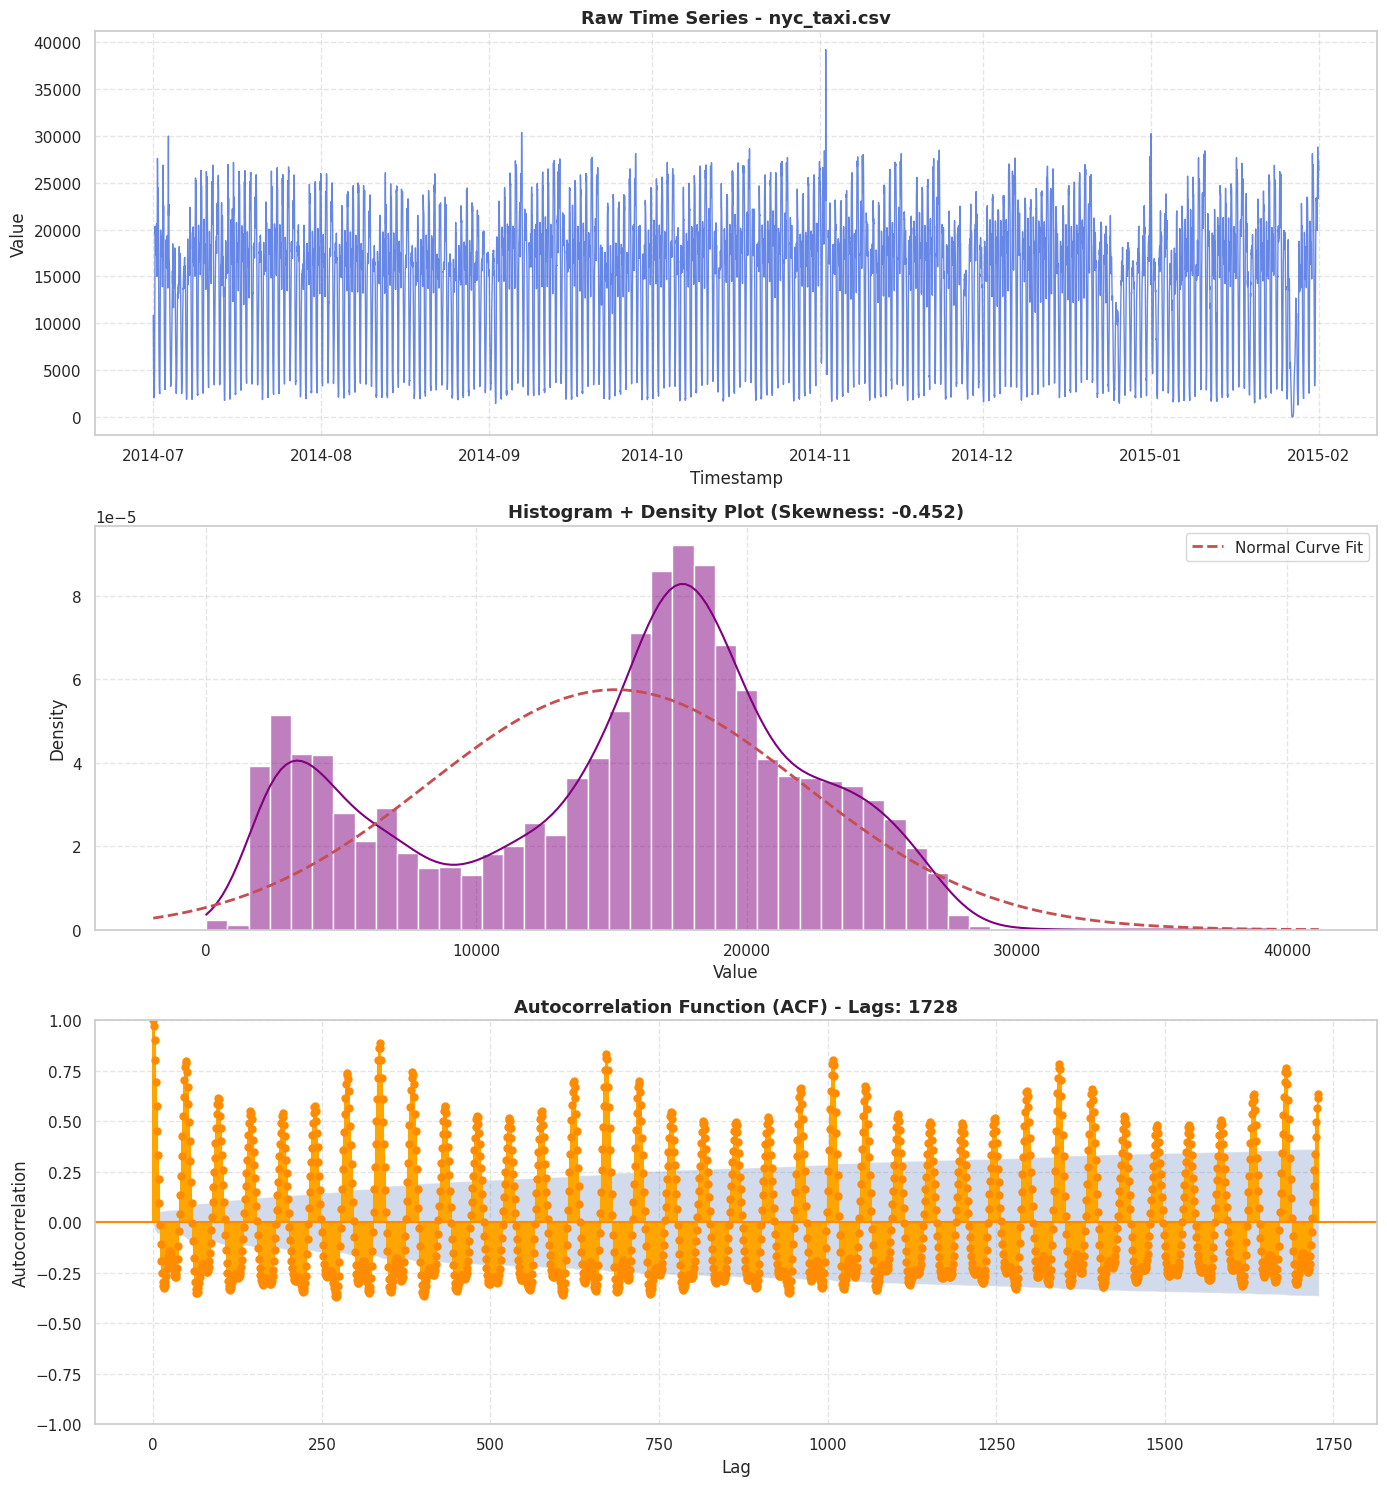


ANALYSIS FOR DATASET: rogue_agent_key_hold.csv


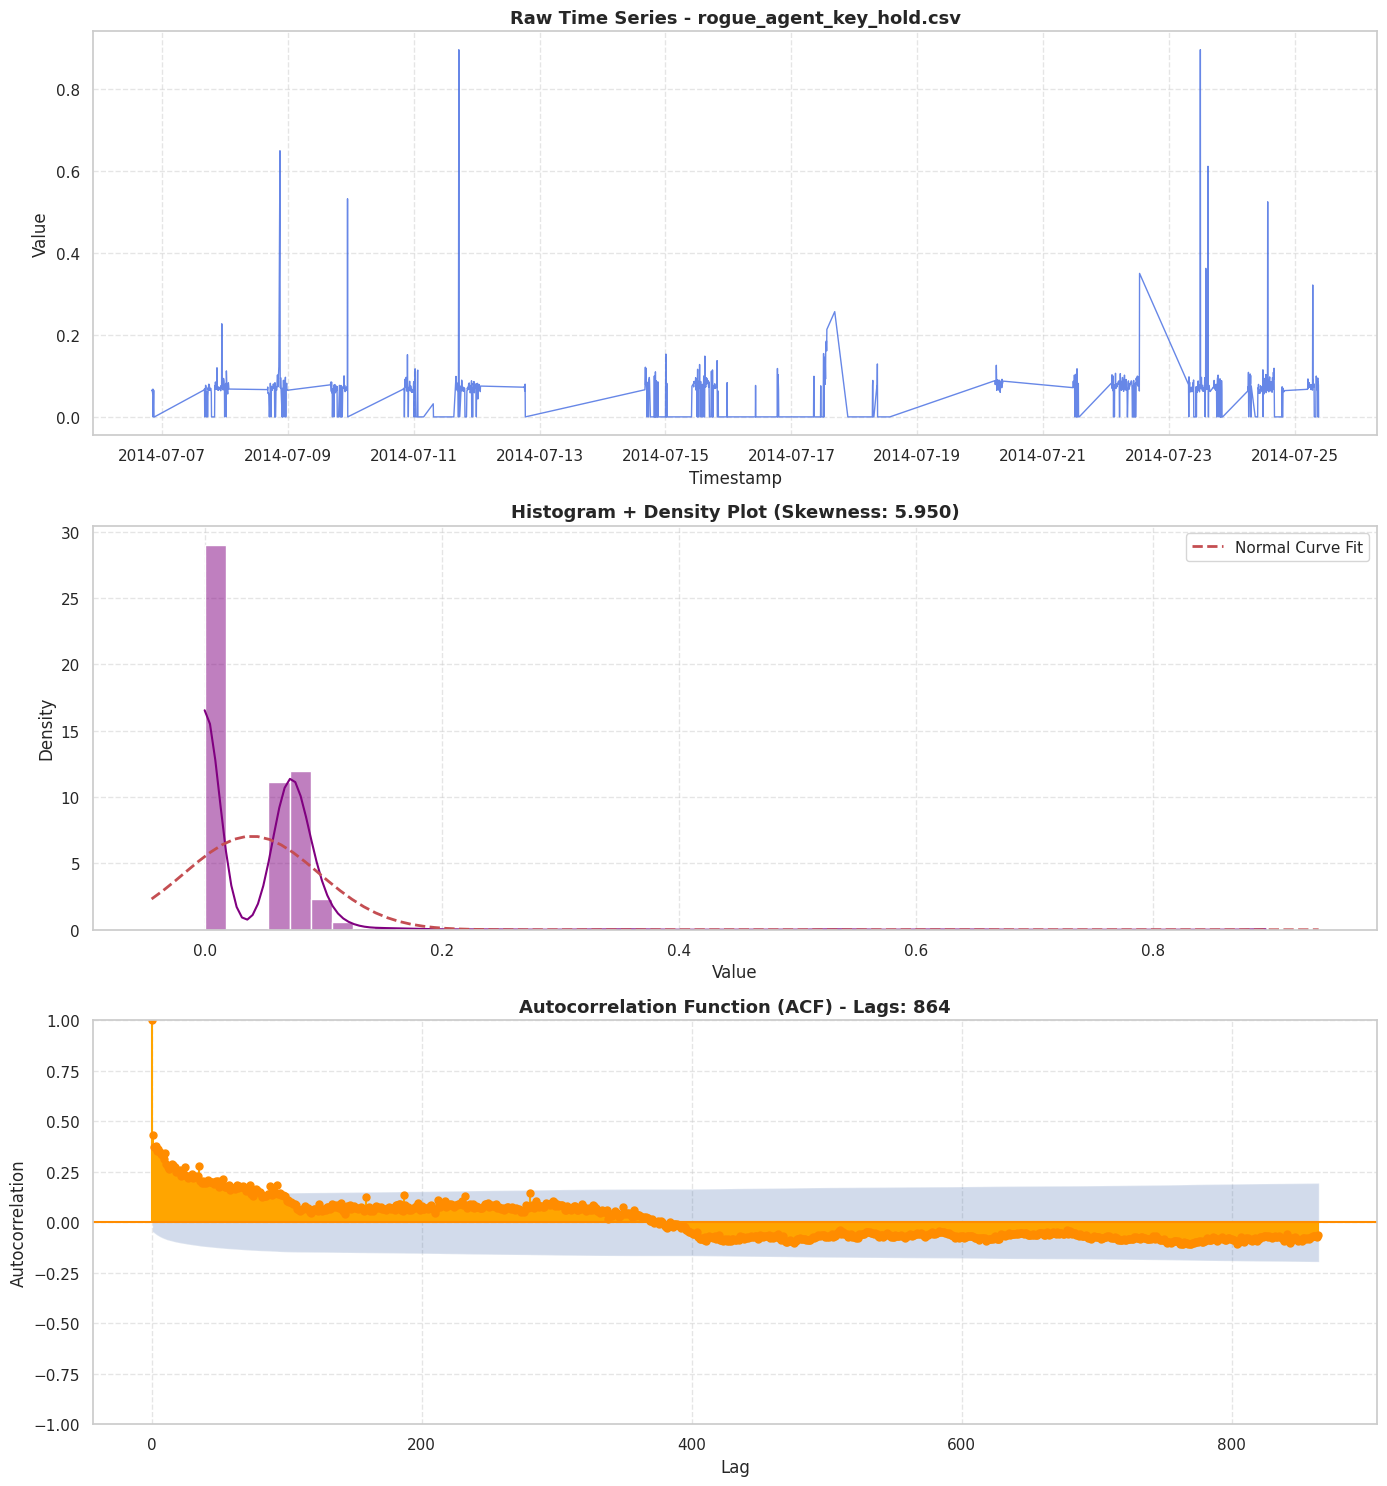


ANALYSIS FOR DATASET: rogue_agent_key_updown.csv


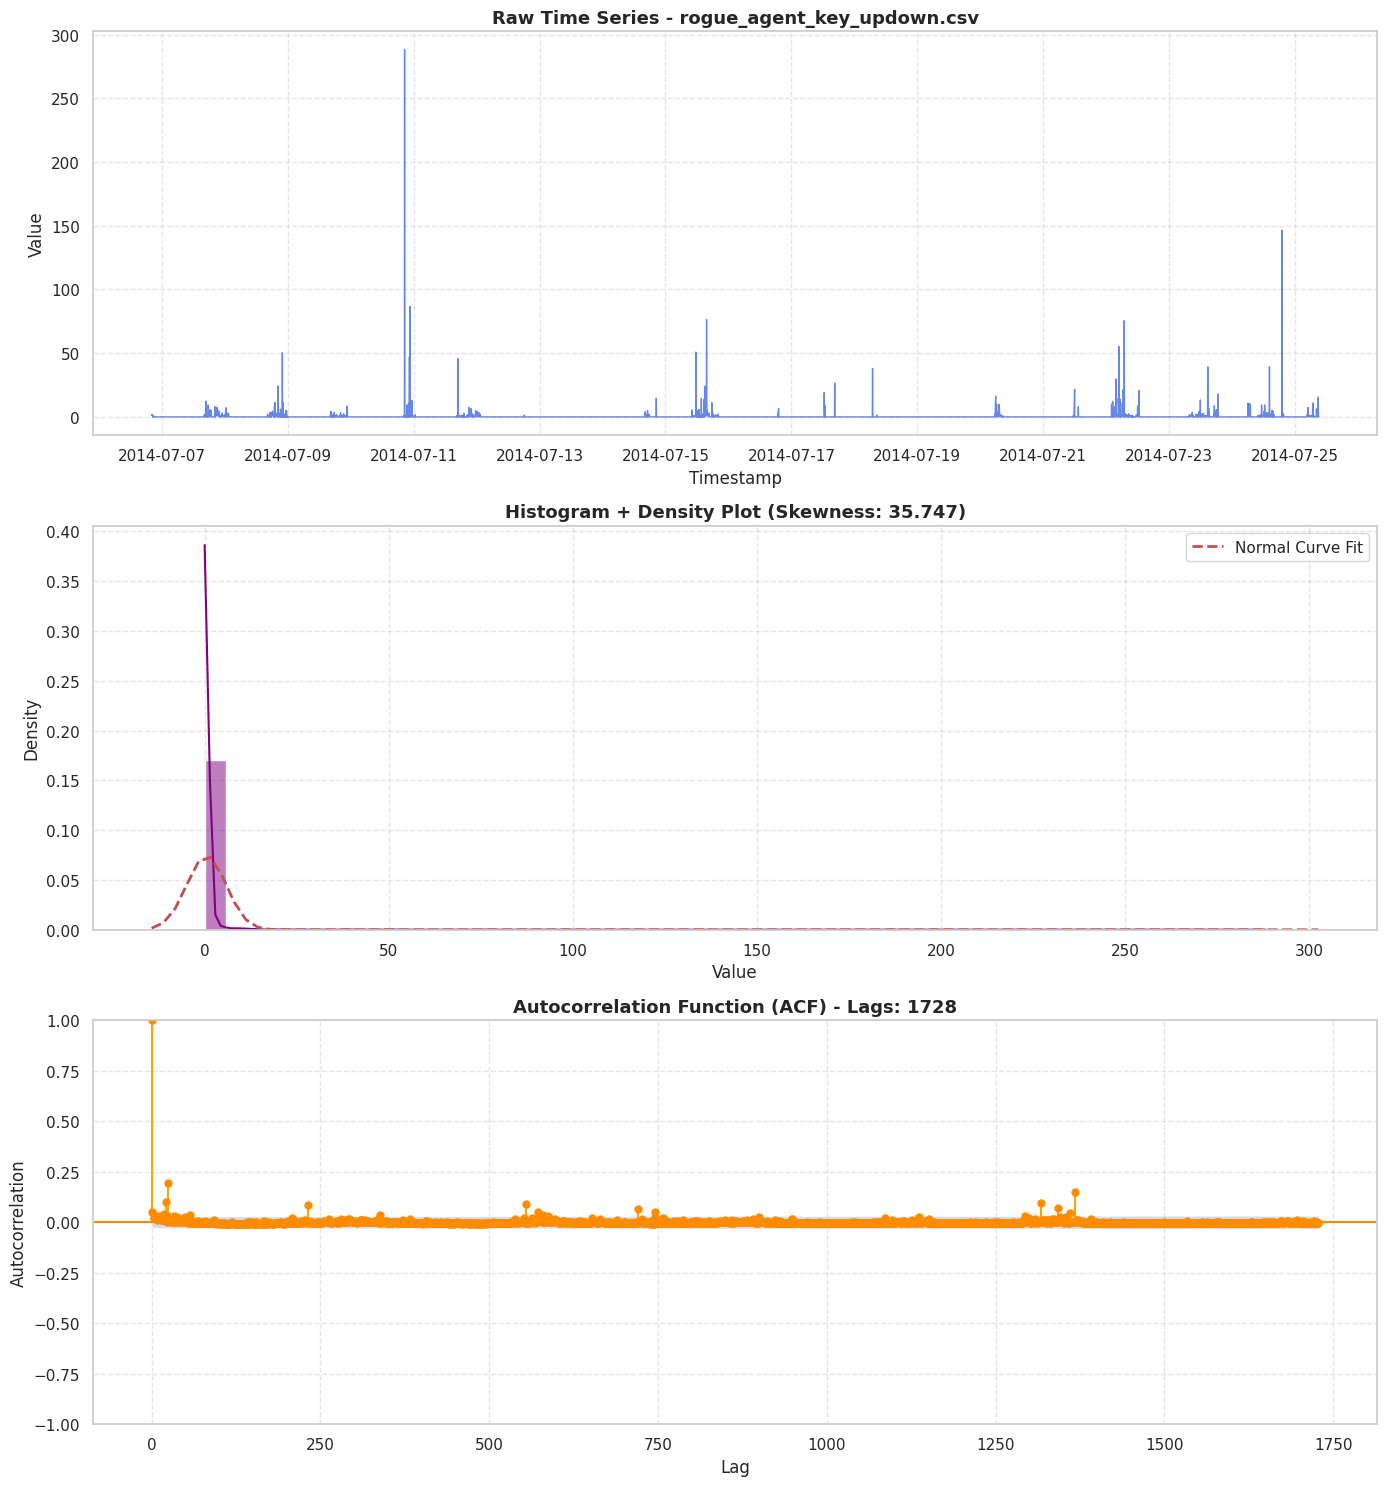

In [4]:
for filename in files:
    df = datasets[filename]
    values = df['value']
    skew_val = stats.skew(values)
    
    print("\n" + "="*80)
    print(f"ANALYSIS FOR DATASET: {filename}")
    print("="*80)
    
    # Create 3-panel subplots
    fig, axes = plt.subplots(3, 1, figsize=(14, 15))
    
    # 1. Raw Time Series
    axes[0].plot(df['timestamp'], values, color='royalblue', alpha=0.8, linewidth=1)
    axes[0].set_title(f'Raw Time Series - {filename}', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Timestamp')
    axes[0].set_ylabel('Value')
    axes[0].grid(True, linestyle='--', alpha=0.5)
    
    # 2. Histogram + Density
    sns.histplot(values, kde=True, ax=axes[1], color='purple', stat='density', bins=50)
    xmin, xmax = axes[1].get_xlim()
    x_norm = np.linspace(xmin, xmax, 100)
    p_norm = stats.norm.pdf(x_norm, values.mean(), values.std())
    axes[1].plot(x_norm, p_norm, 'r--', linewidth=2, label='Normal Curve Fit')
    axes[1].set_title(f'Histogram + Density Plot (Skewness: {skew_val:.3f})', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Value')
    axes[1].set_ylabel('Density')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    # 3. Autocorrelation Function (ACF) - set all base lags into 6 days 
    if 'ambient_temperature' in filename:
        lags = 144 # 6x24=144, hourly frequency
    elif 'ec2_request_latency_system_failure' in filename:
        lags = 1728 # 6x24x12, 5 minutes frequency
    elif 'machine_temperature_system_failure' in filename:
        lags = 1728 # 6x24x12, 5 minutes frequency
    elif 'nyc_taxi' in filename:
        lags = 1728 # 6x24x12=1728, 5 minutes frequency
    elif 'rogue_agent_key_hold' in filename:
        lags = 864 # 6x24x6=864, 10 minutes frequency
    elif 'rogue_agent_key_updown' in filename:
        lags = 1728 # 6x24x12=1728, 5 minutes frequency
    elif len(df) < 3000:
        lags = min(100, len(df)//3)
    else:
        lags = 300
        
    plot_acf(values, lags=lags, ax=axes[2], color='darkorange', vlines_kwargs={"colors": "orange"})
    axes[2].set_title(f'Autocorrelation Function (ACF) - Lags: {lags}', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Lag')
    axes[2].set_ylabel('Autocorrelation')
    axes[2].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()


| **No** | **Dataset**                              | **Stationarity** | **Seasonality** | **Skewness**                             | **Recommended Modeling Method & Rationale**                                                                                                                                                                                                                                                                |
| ------ | ---------------------------------------- | ---------------- | --------------- | ---------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **1**  | **ambient_temperature_system_failure**   | Yes              | Yes             | Slightly left-skewed - Close to Gaussian | **STL + $3\sigma$**:<br><br>  <br><br>Dữ liệu có chu kỳ mùa vụ (Seasonality = Yes) $\rightarrow$ Đi theo nhánh STL Decomposition. Vì đây là 1 metric có phân phối gần chuẩn, residual sẽ rất đơn giản $\rightarrow$ Áp dụng **$3\sigma$** trên tập residual là tối ưu.                                     |
| **2**  | **cpu_utilization_asg_misconfiguration** | Yes              | Yes             | Highly right-skewed - Non-Gaussian       | **STL + $3\sigma$**:<br><br>  <br><br>Có tính mùa vụ $\rightarrow$ Dùng STL Decomposition. Dù xuất hiện các gai (spikes) gây lệch phải, thuật toán cơ bản vẫn là **STL + $3\sigma$** trên residual. (Chỉ nâng cấp lên Deep Learning nếu các gai này mang temporal dependency quá phức tạp).                |
| **3**  | **ec2_request_latency_system_failure**   | Yes              | No              | Moderately right-skewed - Heavy-tailed   | **Autoencoder / LSTM-AE** (Nâng cấp từ $3\sigma$):<br><br>  <br><br>Không có mùa vụ $\rightarrow$ Nhánh gốc là $3\sigma$/EWMA. Tuy nhiên, đặc tính nhiễu cao, phân cụm biến động (volatility) và đuôi dày chứng tỏ **pattern phức tạp, temporal dependency mạnh** $\rightarrow$ Cần mô hình Deep Learning. |
| **4**  | **machine_temperature_system_failure**   | Yes              | No              | Highly left-skewed - Non-Gaussian        | **$3\sigma$ / EWMA**:<br><br>  <br><br>Không có chu kỳ mùa vụ $\rightarrow$ Đi theo nhánh trái. Các sự cố sụt giảm nhiệt độ đột ngột (rơi ra khỏi đám đông) có thể bị bắt dễ dàng bằng ngưỡng thống kê $\rightarrow$ **Giữ phương pháp đơn giản**, không cần DL.                                           |
| **5**  | **nyc_taxi**                             | Yes              | Yes             | Moderately left-skewed - Bimodal         | **STL + $3\sigma$**:<br><br>  <br><br>Dữ liệu có tính mùa vụ mạnh (đa chu kỳ) $\rightarrow$ Đi theo nhánh STL. Sau khi tách bỏ hoàn toàn trend và seasonality, tập residual sẽ biểu diễn các anomaly (như bão tuyết, sự kiện lớn) dễ dàng bị phát hiện bằng **$3\sigma$**.                                 |
| **6**  | **rogue_agent_key_hold**                 | Yes              | No              | Moderately right-skewed - Narrow peak    | **$3\sigma$ / EWMA**:<br><br>  <br><br>Tập dữ liệu nhỏ, phân phối hẹp và không có mùa vụ. Theo cây quyết định, không có dependency nào phức tạp ở đây $\rightarrow$ **Giữ phương pháp đơn giản hơn** để tránh cồng kềnh hệ thống.                                                                          |
| **7**  | **rogue_agent_key_updown**               | Yes              | No              | Slightly right-skewed - Near-Gaussian    | **$3\sigma$ / EWMA**:<br><br>  <br><br>Trường hợp cơ bản và nguyên thủy nhất: Không mùa vụ, 1 metric, phân phối đối xứng và gần chuẩn. Phù hợp hoàn hảo để áp dụng trực tiếp **$3\sigma$ / EWMA**.                                                                                                         |
